### Setting up the data

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Make our plots look a bit more polished
sns.set_theme(style="whitegrid")

# Load all the updated files back into one massive DataFrame for EDA
input_dir = "final_data_updated"
all_files = glob.glob(os.path.join(input_dir, "*.parquet"))

df_list = [pd.read_parquet(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

print(f"Loaded {len(df):,} total rows for visualization!")

Loaded 2,988,763 total rows for visualization!


## Delay by Hour
Let's start by looking at the average train delay by hour of the day.

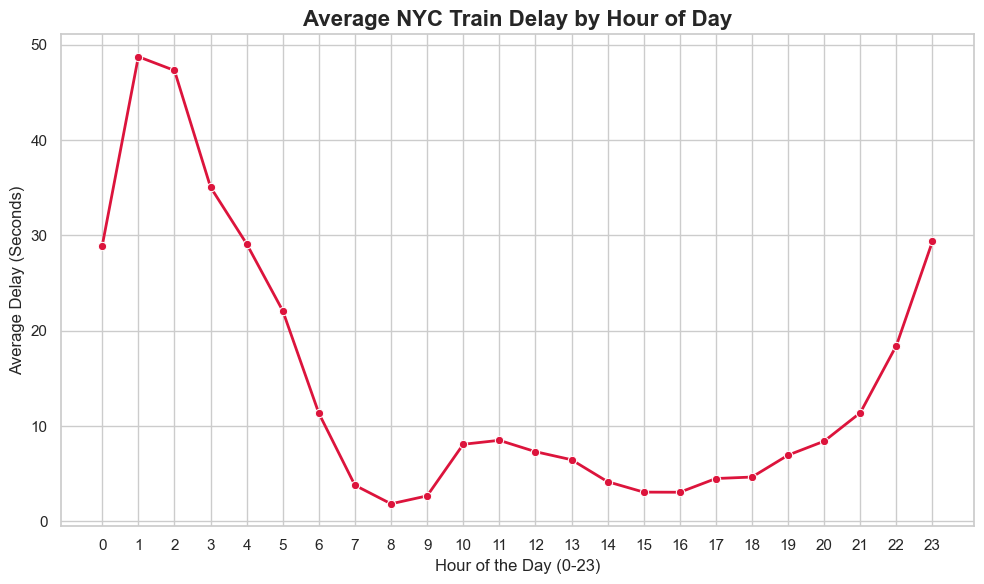

In [42]:
# Group the data by hour and calculate the mean of the average delays
hourly_delays = df.groupby('hour')['avg_delay_seconds'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_delays, x='hour', y='avg_delay_seconds', marker='o', color='crimson', linewidth=2)

plt.title('Average NYC Train Delay by Hour of Day', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Delay (Seconds)', fontsize=12)
plt.xticks(range(0, 24)) # Show every hour on the x-axis

plt.tight_layout()
plt.show()

## Worst Offenders
Now, let's compare the reliability of the different train lines.

/var/folders/_9/ktpt09t972gclym9_kg79rnh0000gn/T/ipykernel_40873/3003152500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=route_delays, x='avg_delay_seconds', y='route_name', palette='viridis')


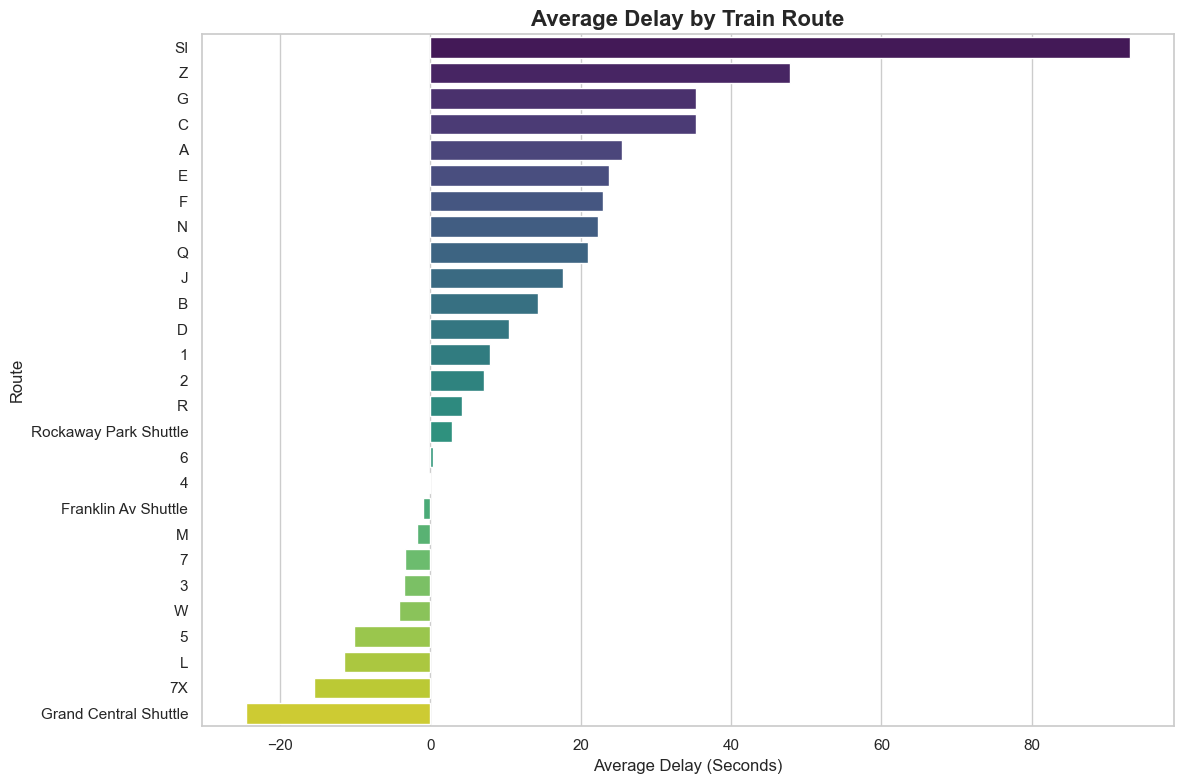

In [43]:
# Group by route name and calculate mean delay, then sort from worst to best
route_delays = df.groupby('route_name')['avg_delay_seconds'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=route_delays, x='avg_delay_seconds', y='route_name', palette='viridis')

plt.title('Average Delay by Train Route', fontsize=16, fontweight='bold')
plt.xlabel('Average Delay (Seconds)', fontsize=12)
plt.ylabel('Route', fontsize=12)

plt.tight_layout()
plt.show()

## Most Delayed Stations
Let's view the top 10 stations with the highest average delay.

/var/folders/_9/ktpt09t972gclym9_kg79rnh0000gn/T/ipykernel_40873/3392147117.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=station_delays, x='avg_delay_seconds', y='stop_name', palette='Reds_r')


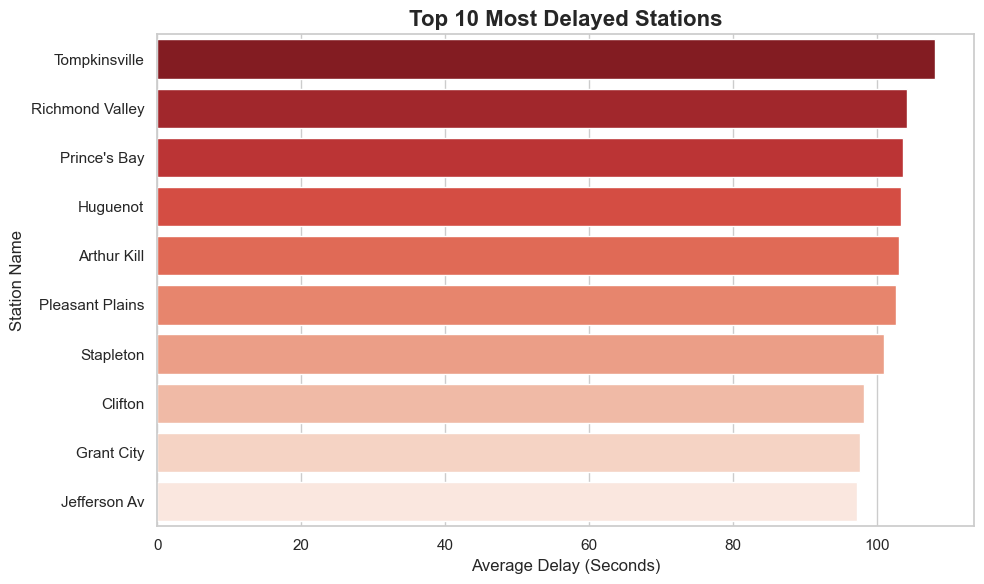

In [44]:
# Group by station name, get mean delay, sort from highest to lowest, and take the top 10
station_delays = df.groupby('stop_name')['avg_delay_seconds'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=station_delays, x='avg_delay_seconds', y='stop_name', palette='Reds_r')

plt.title('Top 10 Most Delayed Stations', fontsize=16, fontweight='bold')
plt.xlabel('Average Delay (Seconds)', fontsize=12)
plt.ylabel('Station Name', fontsize=12)

plt.tight_layout()
plt.show()

Seems like all of these stations are in Staten Island, so let's gather more MTA data and find the top 10 in the other boroughs.

In [45]:
# Fetch official MTA Stations reference data
mta_stations_url = "http://web.mta.info/developers/data/nyct/subway/Stations.csv"
mta_stations = pd.read_csv(mta_stations_url)
borough_mapping = mta_stations[['GTFS Stop ID', 'Borough']].drop_duplicates()

# Merge borough information into dataset
df['base_stop_id'] = df['stop_id'].str[:-1]
merged_df = df.merge(borough_mapping, left_on='base_stop_id', right_on='GTFS Stop ID', how='left')

# Create a reusable plotting function for other boroughs
def plot_top_10_borough(data, borough_code, borough_name, color_palette):
    b_df = data[data['Borough'] == borough_code].copy()

    if b_df.empty:
        print("No data found for", borough_name + ".")
        return

    # Group by station name, get mean delay, sort from highest to lowest, and take top 10
    station_delays = b_df.groupby('stop_name')['avg_delay_seconds'].mean().sort_values(ascending=False).head(10).reset_index()

    # Plot results
    plt.figure(figsize=(10, 6))
    sns.barplot(data=station_delays, x='avg_delay_seconds', y='stop_name', hue='stop_name', palette=color_palette)

    plt.title(f"Top 10 Most Delayed Stations in {borough_name}", fontsize=16, fontweight='bold')
    plt.xlabel("Average Delay (Seconds)", fontsize=12)
    plt.ylabel("Station Name", fontsize=12)

    plt.tight_layout()
    plt.show()

## Top 10 Delayed Stations in Manhattan

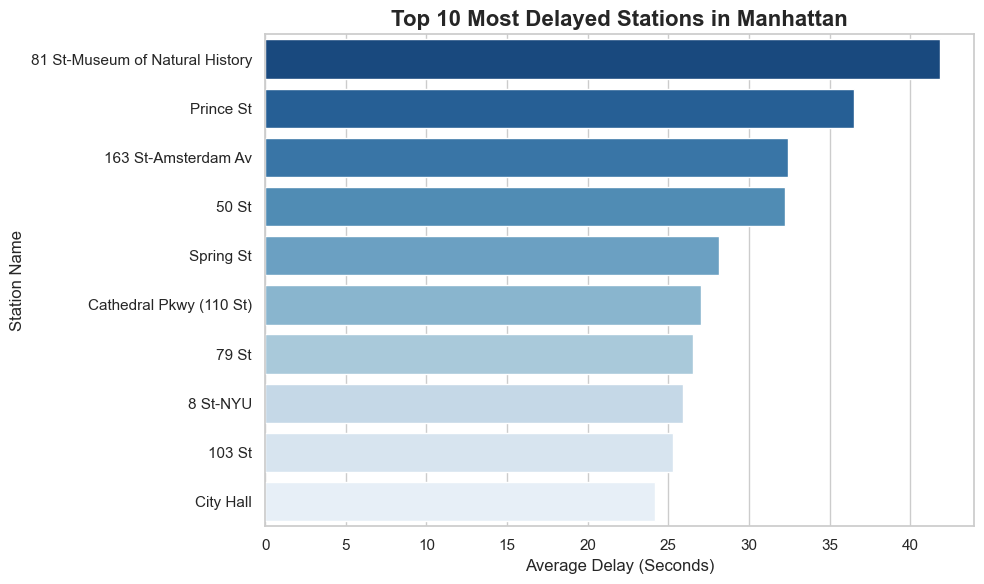

In [46]:
plot_top_10_borough(merged_df, 'M', 'Manhattan', 'Blues_r')

## Top 10 Delayed Stations in Brooklyn

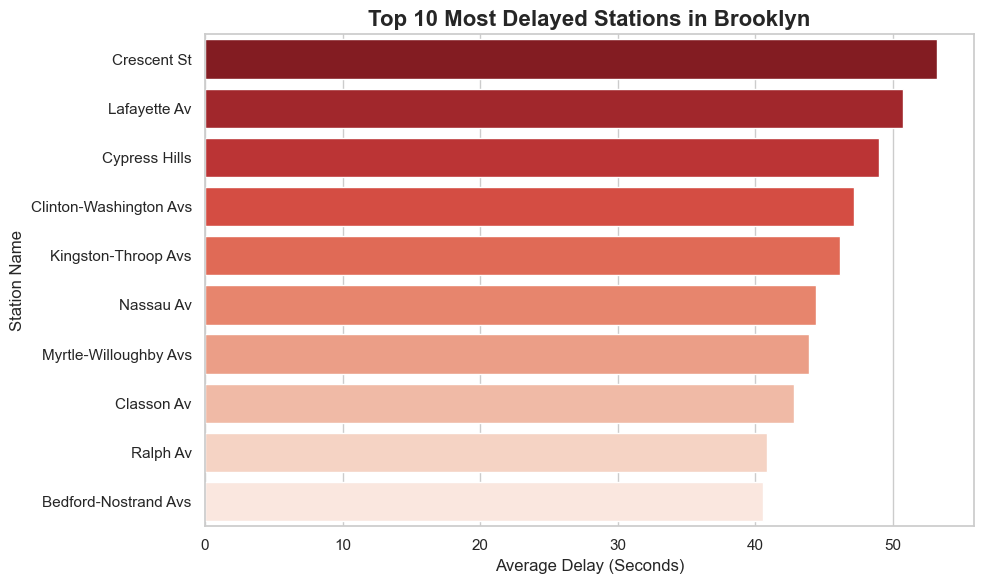

In [47]:
plot_top_10_borough(merged_df, 'Bk', 'Brooklyn', 'Reds_r')

## Top 10 Delayed Stations in Queens

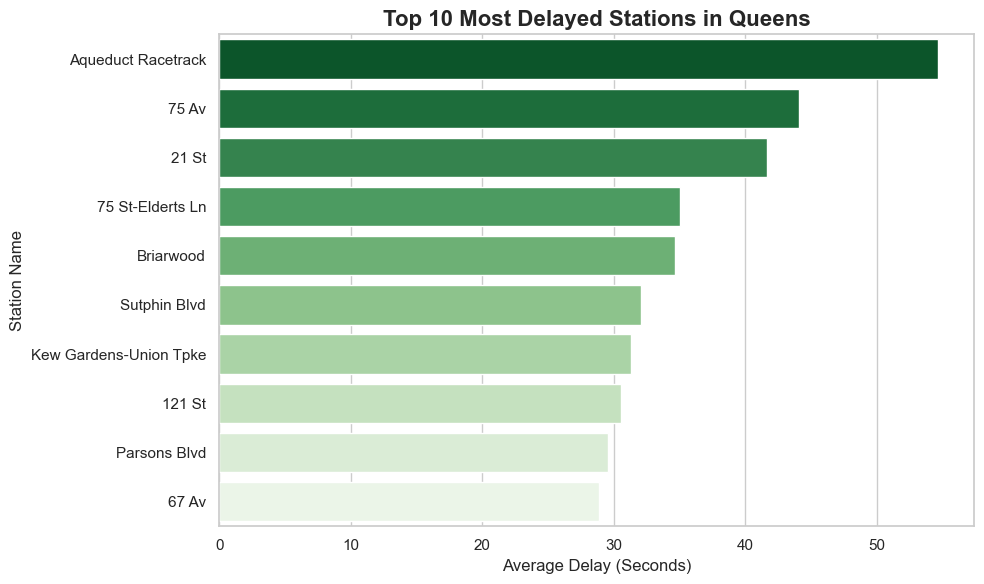

In [48]:
plot_top_10_borough(merged_df, 'Q', 'Queens', 'Greens_r')

## Top 10 Delayed Stations in the Bronx

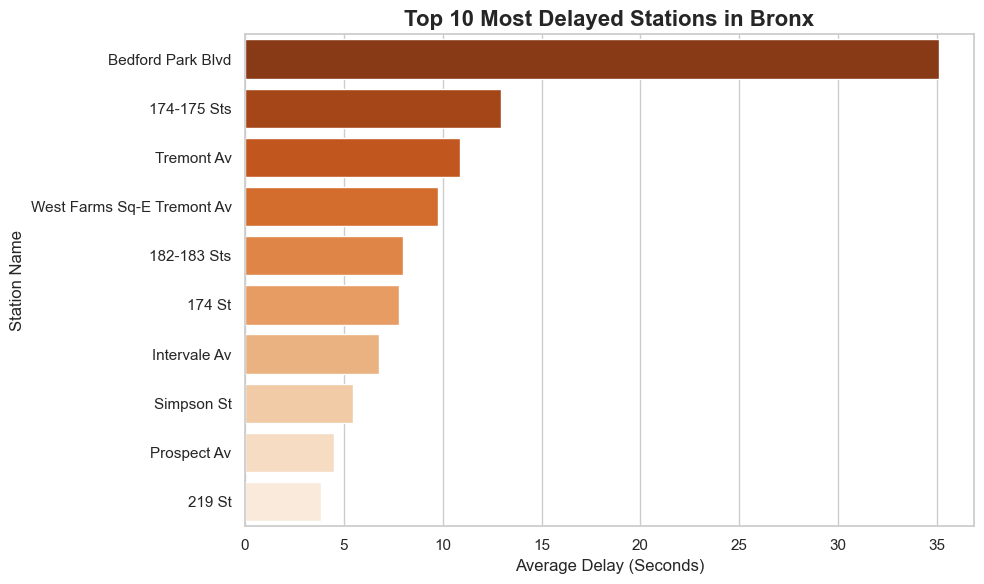

In [49]:
plot_top_10_borough(merged_df, 'Bx', 'Bronx', 'Oranges_r')

## Day of Week vs Hour Heatmap
Let's create a heatmap showing the worst times to ride the train.

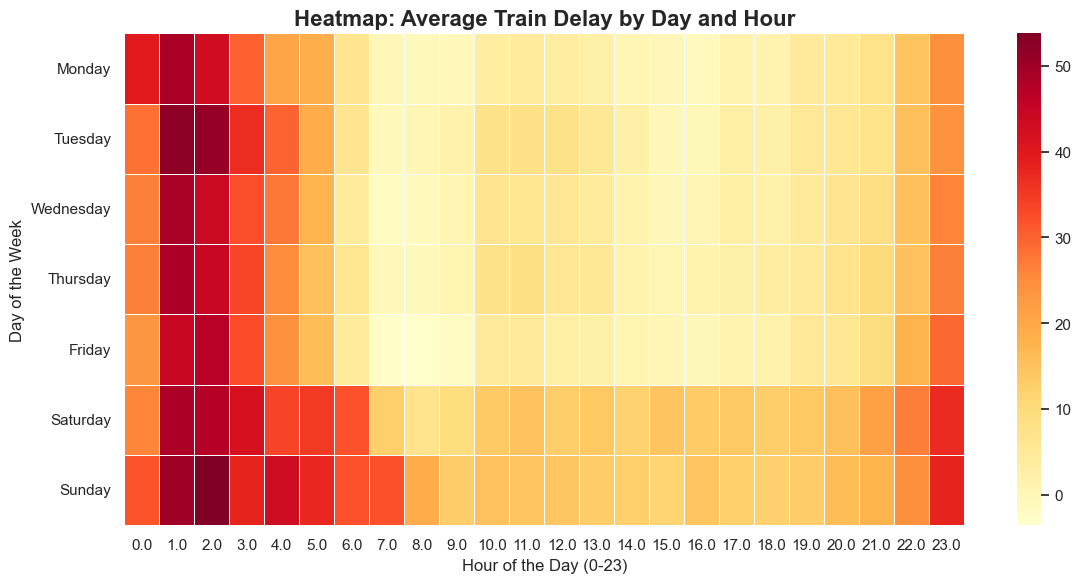

In [50]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.pivot_table(index='day_of_week', columns='hour', values='avg_delay_seconds', aggfunc='mean')

heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, linewidths=.5)

plt.title("Heatmap: Average Train Delay by Day and Hour", fontsize=16, fontweight='bold')
plt.xlabel("Hour of the Day (0-23)", fontsize=12)
plt.ylabel("Day of the Week", fontsize=12)

plt.tight_layout()
plt.show()

## Delay by Season
Finally, let's visualize the train delay by season.

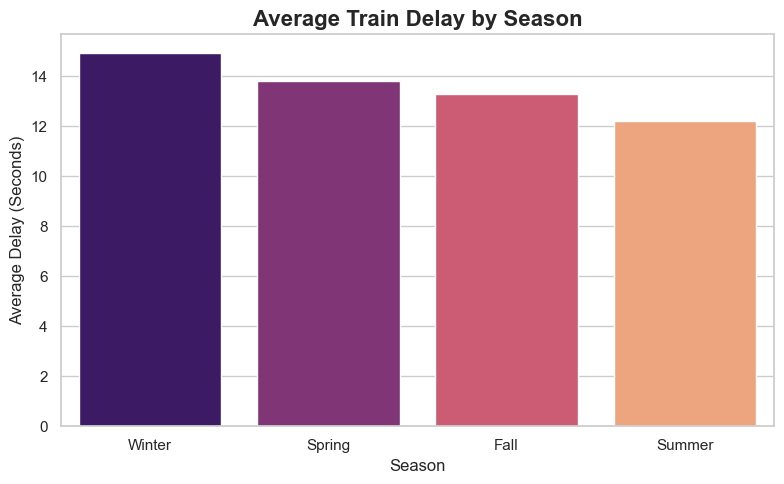

In [51]:
season_delays = df.groupby('season')['avg_delay_seconds'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=season_delays, x='season', y='avg_delay_seconds', hue='season', palette='magma')

plt.title("Average Train Delay by Season", fontsize=16, fontweight='bold')
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Delay (Seconds)", fontsize=12)

plt.tight_layout()
plt.show()